<a href="https://colab.research.google.com/github/fatymali007/intro2ML_assignment1/blob/main/Intro_to_ML_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

movies_df= pd.read_csv("/content/drive/MyDrive/t7/Intro_to _ML_assignment1/movies.csv")
users_df=pd.read_csv("/content/drive/MyDrive/t7/Intro_to _ML_assignment1/ratings.csv")

print(movies_df.head())
print(f"movies df shape:{movies_df.shape}")
print(users_df.head())
print(f"users df shape:{users_df.shape}")

no_movies=movies_df['movieId'].nunique()
no_users=users_df['userId'].nunique()
no_ratings=users_df['rating'].count()
total_ratings= no_movies*no_users
#sparsity= 1-density
#density= #non-zero elements/total number of elements in the matrix
sparsity= 1-(no_ratings/total_ratings)
Report=[]
Report.append("Report:")
Report.append(f"number of unique users:{no_users}")
Report.append(f"number of unique movies:{no_movies}")
Report.append(f"number of ratings:{no_ratings}")
Report.append(f"total ratings:{total_ratings}")
Report.append(f"Sparsity:{sparsity}")

print(f"\n")
for op in Report:
  print(op)

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
movies df shape:(9742, 3)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
users df shape:(100836, 4)


Report:
number of unique users:610
number of unique movies:9742
number of ratings:100836
total ratings:5942620
Sparsity:0.

In [ ]:
#Pivot table approach to build the matrix
rating_matrix = users_df.pivot_table(index="userId", columns="movieId", values="rating")
rating_matrix = rating_matrix.reindex(columns= movies_df['movieId'])
rating_matrix.shape

(610, 9742)

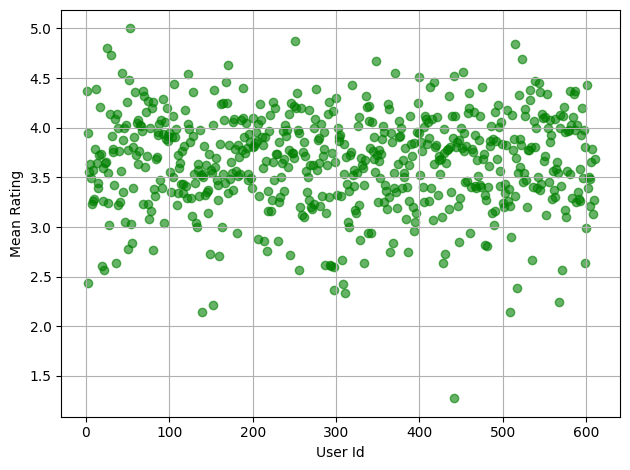

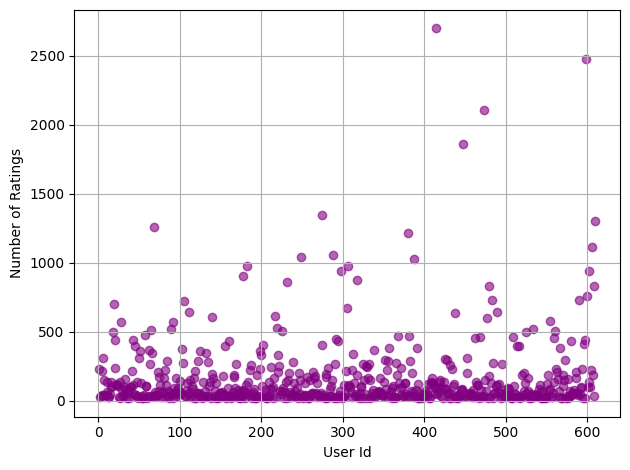

In [ ]:
import matplotlib.pyplot as plt

user_mean=users_df.groupby('userId')['rating'].mean()
user_count=users_df.groupby('userId')['rating'].count()

# Scatter of teh mean rating per user
plt.figure()
plt.scatter(user_mean.index,user_mean.values ,alpha=0.6, color='green')
plt.xlabel('User Id')
plt.ylabel('Mean Rating')
plt.grid(True)
plt.tight_layout()
# Scatter plot of the number of ratings per users
plt.figure()
plt.scatter(user_count.index,user_count.values ,alpha=0.6, color='purple')
plt.xlabel('User Id')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.tight_layout()

plt.show()